In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import cv2
import pytesseract

import numpy as np
import pandas as pd
import copy
import os
import glob

import datetime as dt
import time
from timethis import timethis
import subprocess
from common_params import parent_directory_images, parent_directory_url_csvs
from preprocess_data_fns import body_style_dict
# from preprocess_data_fns import (
#     create_image_files_df, get_predicted_categories_clip, categorize_and_plot, categories,
#     crop_out_text, banner_text_box, preprocess_image_for_banner_text
#
# )

In [7]:
label_dict = {v:k for k,v in body_style_dict.items()}
label_dict

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}

In [8]:
output_filename_rules = f'{parent_directory_url_csvs}df_clip_categorize_rules.csv'
output_filename_croppped = f'{parent_directory_url_csvs}df_clip_categorize_cropped.csv'
output_filename_train_val_holdout = f'{parent_directory_url_csvs}df_train_val_hold.csv'

In [9]:

df=pd.read_csv(output_filename_train_val_holdout)
print(df.shape)
df.head()

(8775, 9)


,filepath,filename,filepath_to_use,vehicle_id,partition,make,model,body_style,body_style_index
0,/Users/levgolod/Projects/car_classifier/data/a...,376e2b73f7e04c0abb53dbed174a7bc8.jpg,/Users/levgolod/Projects/car_classifier/data/a...,701932606,val,bmw,3-series,sedan,0
1,/Users/levgolod/Projects/car_classifier/data/a...,ac2d692d18f64c6b9eb4835d24bd42eb.jpg,/Users/levgolod/Projects/car_classifier/data/a...,701932606,val,bmw,3-series,sedan,0
2,/Users/levgolod/Projects/car_classifier/data/a...,b4ade0a7c1c5426496acf7b3d45eb8d5.jpg,/Users/levgolod/Projects/car_classifier/data/a...,701932606,val,bmw,3-series,sedan,0
3,/Users/levgolod/Projects/car_classifier/data/a...,e9ec18b6971c4b4a88bfdfd6da9cc331.jpg,/Users/levgolod/Projects/car_classifier/data/a...,701932606,val,bmw,3-series,sedan,0
4,/Users/levgolod/Projects/car_classifier/data/a...,50b55b74a0e04e8d9928d7bc48255f6f.jpg,/Users/levgolod/Projects/car_classifier/data/a...,704716526,train,bmw,3-series,sedan,0


In [10]:
input_files_train = list(df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].values)
input_files_train[0]

array(['/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-704716526/50b55b74a0e04e8d9928d7bc48255f6f.jpg',
       0], dtype=object)

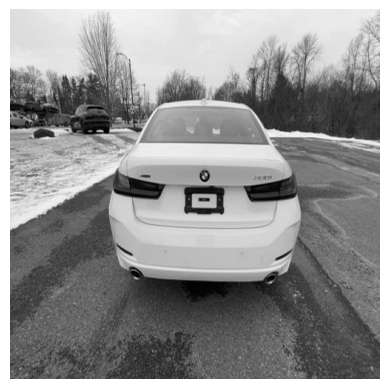

In [11]:
x=input_files_train[0]

image_path=x[0]
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image= cv2.resize(image, (500, 500), interpolation=cv2.INTER_CUBIC)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_array = np.array(gray)
# print(image_array.shape)
plt.imshow(image_array, cmap='gray')
plt.axis("off")  # Hide axis
plt.show()

In [12]:
def process_image_files(input_files:list) -> list:
    results=[]
    for i,x in enumerate(input_files):
        if i % 100 ==0:
            print(i, dt.datetime.now())
        label = x[1]
        image_path=x[0]
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image= cv2.resize(image, (500, 500), interpolation=cv2.INTER_CUBIC)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image_array = np.array(gray)
        results+=[(image_array,label)]
    #
    return results




In [13]:
input_files_train = list(df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].values)

processed_images_train = process_image_files(input_files_train[:10])
len(processed_images_train)

0 2025-02-25 12:49:36.502712


10

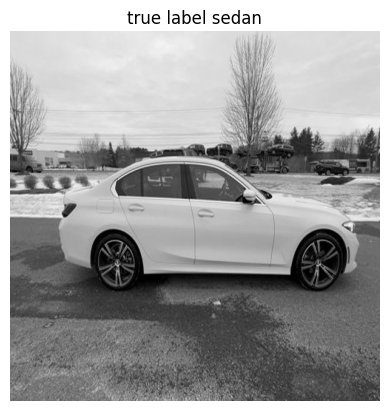

In [14]:
i=5
image_array = processed_images_train[i][0]
label = label_dict.get( processed_images_train[i][1])
plt.imshow(image_array, cmap='gray')
plt.axis("off")  # Hide axis
plt.title(f"true label {label}")
plt.show()